# AutoSelect 教程（基于当前 `scptensor.autoselect`）

本教程只使用当前模块中真实可用的接口，目标是：

1. 用快捷函数完成 stable preprocessing stages 中的 `normalize` / `impute` 自动选择。
2. 演示有批次列时的 `integrate` 输入要求与报告读取。
3. 用 `AutoSelector` 一次跑多阶段（`normalize -> impute -> reduce -> cluster`）。
   其中 `reduce` / `cluster` 属于 optional experimental downstream helper，不属于 stable preprocessing release。
4. 理解策略预设（`speed` / `balanced` / `quality`）与报告导出。

说明：

- 报告里出现的 `raw_norm_median`、`raw_norm_median_iterative_svd` 等名字，是 AutoSelect comparison artifact naming，不等同于仓库 canonical `norm / imputed`。
- 若要把选中结果纳入 stable mainline，应显式 promote / rename，并保留 provenance。

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import scipy.sparse as sp

import scptensor.autoselect as auto
from scptensor.io import load_diann

warnings.filterwarnings(
    "ignore",
    message="n_jobs value 1 overridden to 1 by setting random_state.*",
    category=UserWarning,
)

In [2]:
def locate_project_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "data" / "dia" / "diann").exists():
            return candidate
    raise FileNotFoundError("Cannot locate project root containing data/dia/diann")


def load_diann_subset(
    report_path: Path,
    assay_name: str = "proteins",
    n_samples: int = 120,
    n_features: int = 300,
):
    container = load_diann(
        report_path,
        level="protein",
        table_format="long",
        assay_name=assay_name,
    )

    assay = container.assays[assay_name]
    layer = assay.layers["raw"]

    keep_samples = min(n_samples, container.n_samples)
    keep_features = min(n_features, assay.n_features)

    layer.X = np.asarray(layer.X[:keep_samples, :keep_features]).copy()
    if layer.M is not None:
        layer.M = np.asarray(layer.M[:keep_samples, :keep_features]).copy()

    container.obs = container.obs.slice(0, keep_samples)
    assay.var = assay.var.slice(0, keep_features)
    return container


def stage_results_table(stage_report: auto.StageReport) -> pl.DataFrame:
    rows = [
        {
            "method": r.method_name,
            "selection_score": r.selection_score,
            "overall_score": r.overall_score,
            "execution_time_s": r.execution_time,
            "layer_or_key": r.layer_name,
            "n_repeats": r.n_repeats,
            "error": r.error,
        }
        for r in stage_report.results
    ]
    df = pl.DataFrame(rows)
    if df.is_empty():
        return df
    return (
        df.with_columns(
            pl.when(pl.col("selection_score").is_null())
            .then(-1.0)
            .otherwise(pl.col("selection_score"))
            .alias("_rank")
        )
        .sort("_rank", descending=True)
        .drop("_rank")
    )


def pipeline_overview(report: auto.AutoSelectReport) -> pl.DataFrame:
    rows = []
    for stage_name, stage_report in report.stages.items():
        rows.append(
            {
                "stage": stage_name,
                "best_method": stage_report.best_method,
                "input_assay": stage_report.input_assay,
                "input_layer": stage_report.input_layer,
                "output_assay": stage_report.output_assay,
                "output_layer": stage_report.output_layer,
                "output_obs_key": stage_report.output_obs_key,
                "success_rate": stage_report.success_rate,
            }
        )
    return pl.DataFrame(rows)

In [3]:
ROOT = locate_project_root()
DIANN_REPORT = ROOT / "data" / "dia" / "diann" / "PXD054343" / "1_SC_LF_report.tsv"
container = load_diann_subset(DIANN_REPORT, n_samples=120, n_features=300)

raw = container.assays["proteins"].layers["raw"].X
print(f"Input: {DIANN_REPORT.name}")
print(f"Shape: {container.n_samples} samples x {container.assays['proteins'].n_features} proteins")
print(f"Missing rate (raw): {np.isnan(raw).mean():.2%}")
print(f"obs columns: {container.obs.columns}")

Input: 1_SC_LF_report.tsv
Shape: 24 samples x 300 proteins
Missing rate (raw): 14.67%
obs columns: ['_index']


## 1. 策略预设（selection strategy）

`AutoSelector` 和所有快捷函数都支持三种策略：
- `speed`: 更偏向运行速度
- `balanced`: 质量和速度折中（默认）
- `quality`: 更偏向质量分数


In [4]:
preset_names = auto.list_strategy_presets()
print("Available presets:", preset_names)

preset_df = pl.DataFrame(
    [
        {
            "name": name,
            "quality_weight": auto.get_strategy_preset(name).quality_weight,
            "runtime_weight": auto.get_strategy_preset(name).runtime_weight,
            "description": auto.get_strategy_preset(name).description,
        }
        for name in preset_names
    ]
)

preset_df

Available presets: ['speed', 'balanced', 'quality']


name,quality_weight,runtime_weight,description
str,f64,f64,str
"""speed""",0.65,0.35,"""Favor faster methods while ret…"
"""balanced""",0.85,0.15,"""Prefer quality while mildly fa…"
"""quality""",1.0,0.0,"""Prioritize score quality only."""


## 2. 单阶段快捷函数：`auto_normalize`

In [5]:
container_norm, norm_report = auto.auto_normalize(
    container=container,
    assay_name="proteins",
    source_layer="raw",
    keep_all=True,
    selection_strategy="balanced",
    n_repeats=1,
)

print(f"Stage: {norm_report.stage_name}")
print(f"Best method: {norm_report.best_method}")
print(f"Best layer: {norm_report.best_result.layer_name if norm_report.best_result else 'N/A'}")
print(norm_report.recommendation_reason)

stage_results_table(norm_report)

Stage: normalize
Best method: norm_median
Best layer: raw_norm_median
Best 'balanced' selection score (0.7127) from 5 successful methods (n_repeats=1).


method,selection_score,overall_score,execution_time_s,layer_or_key,n_repeats,error
str,f64,f64,f64,str,i64,null
"""norm_median""",0.712666,0.667382,0.00947,"""raw_norm_median""",1,null
"""norm_quantile""",0.666932,0.644565,0.011422,"""raw_norm_quantile""",1,null
"""norm_mean""",0.649031,0.587096,0.009129,"""raw_norm_mean""",1,null
"""norm_trqn""",0.572547,0.637751,0.017986,"""raw_norm_trqn""",1,null
"""norm_none""",0.544631,0.640743,0.020243,"""raw_norm_none""",1,null


## 3. 在最佳标准化层上执行 `auto_impute`

In [6]:
norm_layer = norm_report.best_result.layer_name if norm_report.best_result else "raw"
missing_before = float(np.isnan(container_norm.assays["proteins"].layers[norm_layer].X).mean())

container_imp, impute_report = auto.auto_impute(
    container=container_norm,
    assay_name="proteins",
    source_layer=norm_layer,
    keep_all=False,
    selection_strategy="quality",
    n_repeats=1,
)

imp_layer = impute_report.best_result.layer_name if impute_report.best_result else norm_layer
missing_after = float(np.isnan(container_imp.assays["proteins"].layers[imp_layer].X).mean())

print(f"Stage: {impute_report.stage_name}")
print(f"Best method: {impute_report.best_method}")
print(f"Input layer:  {norm_layer}")
print(f"Output layer: {imp_layer}")
print(f"Missing rate: {missing_before:.2%} -> {missing_after:.2%}")

stage_results_table(impute_report)

Stage: impute
Best method: iterative_svd
Input layer:  raw_norm_median
Output layer: raw_norm_median_iterative_svd
Missing rate: 14.67% -> 0.00%


method,selection_score,overall_score,execution_time_s,layer_or_key,n_repeats,error
str,f64,f64,f64,str,i64,null
"""iterative_svd""",0.96969,0.96969,0.051157,"""raw_norm_median_iterative_svd""",1,null
"""softimpute""",0.96642,0.96642,0.074526,"""raw_norm_median_softimpute""",1,null
"""knn""",0.950756,0.950756,0.010194,"""raw_norm_median_knn""",1,null
"""lls""",0.936949,0.936949,2.576087,"""raw_norm_median_lls""",1,null
"""bpca""",0.830185,0.830185,0.030156,"""raw_norm_median_bpca""",1,null
…,…,…,…,…,…,…
"""row_mean""",0.610285,0.610285,0.001501,"""raw_norm_median_row_mean""",1,null
"""row_median""",0.579699,0.579699,0.002363,"""raw_norm_median_row_median""",1,null
"""half_row_min""",0.564693,0.564693,0.001531,"""raw_norm_median_half_row_min""",1,null


## 4. 多阶段流水线：`AutoSelector.run`

这里演示当前代码可用的四个常见阶段：
`normalize -> impute -> reduce -> cluster`

注意：

- `reduce` / `cluster` 仅用于 exploratory downstream 分析，属于 experimental helper，不构成 stable preprocessing release 的验收边界。
- 若 `obs` 中已有合格的批次列，stable preprocessing stage 还可继续接 `integrate`；本教程把 `integrate` 单独放在下一节，只是因为它有额外输入前提。

In [7]:
selector = auto.AutoSelector(
    stages=["normalize", "impute", "reduce", "cluster"],
    keep_all=False,
    selection_strategy="balanced",
    n_repeats=1,
)

result_container, full_report = selector.run(
    container=container,
    assay_name="proteins",
    initial_layer="raw",
)

print(full_report.summary())

/home/shenshang/projects/ScpTensor/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AutoSelect Report Summary

Total stages: 4
Total time: 32.84 seconds


NORMALIZE
----------------------------------------
  Methods tested: 5
  Success rate: 100.0%
  Best method: norm_median
  Overall score: 0.6674
  Reason: Best 'balanced' selection score (0.7156) from 5 successful methods (n_repeats=1).

IMPUTE
----------------------------------------
  Methods tested: 13
  Success rate: 100.0%
  Best method: iterative_svd
  Overall score: 0.9697
  Reason: Best 'balanced' selection score (0.9739) from 13 successful methods (n_repeats=1).

REDUCE
----------------------------------------
  Methods tested: 3
  Success rate: 33.3%
  Best method: umap
  Overall score: 0.6727
  Reason: Best 'balanced' selection score (0.7218) from 1 successful methods (n_repeats=1).

CLUSTER
----------------------------------------
  Methods tested: 2
  Success rate: 50.0%
  Best method: kmeans
  Overall score: 0.4264
  Reason: Best 'balanced' selection score (0.5125) from 1 successful methods (n_repeats=

In [8]:
overview = pipeline_overview(full_report)
overview

stage,best_method,input_assay,input_layer,output_assay,output_layer,output_obs_key,success_rate
str,str,str,str,str,str,str,f64
"""normalize""","""norm_median""","""proteins""","""raw""","""proteins""","""raw_norm_median""",null,1.0
"""impute""","""iterative_svd""","""proteins""","""raw_norm_median""","""proteins""","""raw_norm_median_iterative_svd""",null,1.0
"""reduce""","""umap""","""proteins""","""raw_norm_median_iterative_svd""","""umap""","""X""",null,0.333333
"""cluster""","""kmeans""","""umap""","""X""","""umap""","""X""","""kmeans_k5""",0.5


In [9]:
if "cluster" in full_report.stages:
    cluster_key = full_report.stages["cluster"].output_obs_key
    print("Cluster labels key:", cluster_key)
    if cluster_key is not None and cluster_key in result_container.obs.columns:
        print(result_container.obs.select(cluster_key).head(5))

Cluster labels key: kmeans_k5
shape: (5, 1)
┌───────────┐
│ kmeans_k5 │
│ ---       │
│ str       │
╞═══════════╡
│ 2         │
│ 2         │
│ 2         │
│ 1         │
│ 1         │
└───────────┘


## 5. 可选：`integrate` 阶段（需要批次列）

`integrate` 会校验 `obs` 中是否存在批次列（默认 `batch`，可用 `batch_key` 改名）。
如果没有该列，应先在 `obs` 中准备好批次标签。


In [10]:
BATCH_KEY = "batch"

if BATCH_KEY in container_imp.obs.columns:
    container_int, integrate_report = auto.auto_integrate(
        container=container_imp,
        assay_name="proteins",
        source_layer=imp_layer,
        keep_all=False,
        batch_key=BATCH_KEY,
        selection_strategy="balanced",
        n_repeats=1,
    )

    print(f"Stage: {integrate_report.stage_name}")
    print(f"Best method: {integrate_report.best_method}")
    print(
        f"Output layer: {integrate_report.best_result.layer_name if integrate_report.best_result else 'N/A'}"
    )
    stage_results_table(integrate_report)
else:
    print(
        f"Skip integrate: obs 中未找到批次列 '{BATCH_KEY}'。请先添加批次列后再执行 auto_integrate。"
    )

Skip integrate: obs 中未找到批次列 'batch'。请先添加批次列后再执行 auto_integrate。


## 6. 科研风格绘图参数优化（Publication Style）

在 AutoSelect 场景中，同样推荐使用 `viz.base` 的统一科研风格参数：

- `PlotStyle.apply_style(theme="science", dpi=300)`：统一字体、线宽、导出分辨率与配色循环
- `heatmap`：展示标准化/插补后矩阵子集（含 colorbar 标签）
- `scatter(mask_style="explicit")`：显式标记含缺失样本
- `violin(alpha=...)`：展示按分组的分布差异


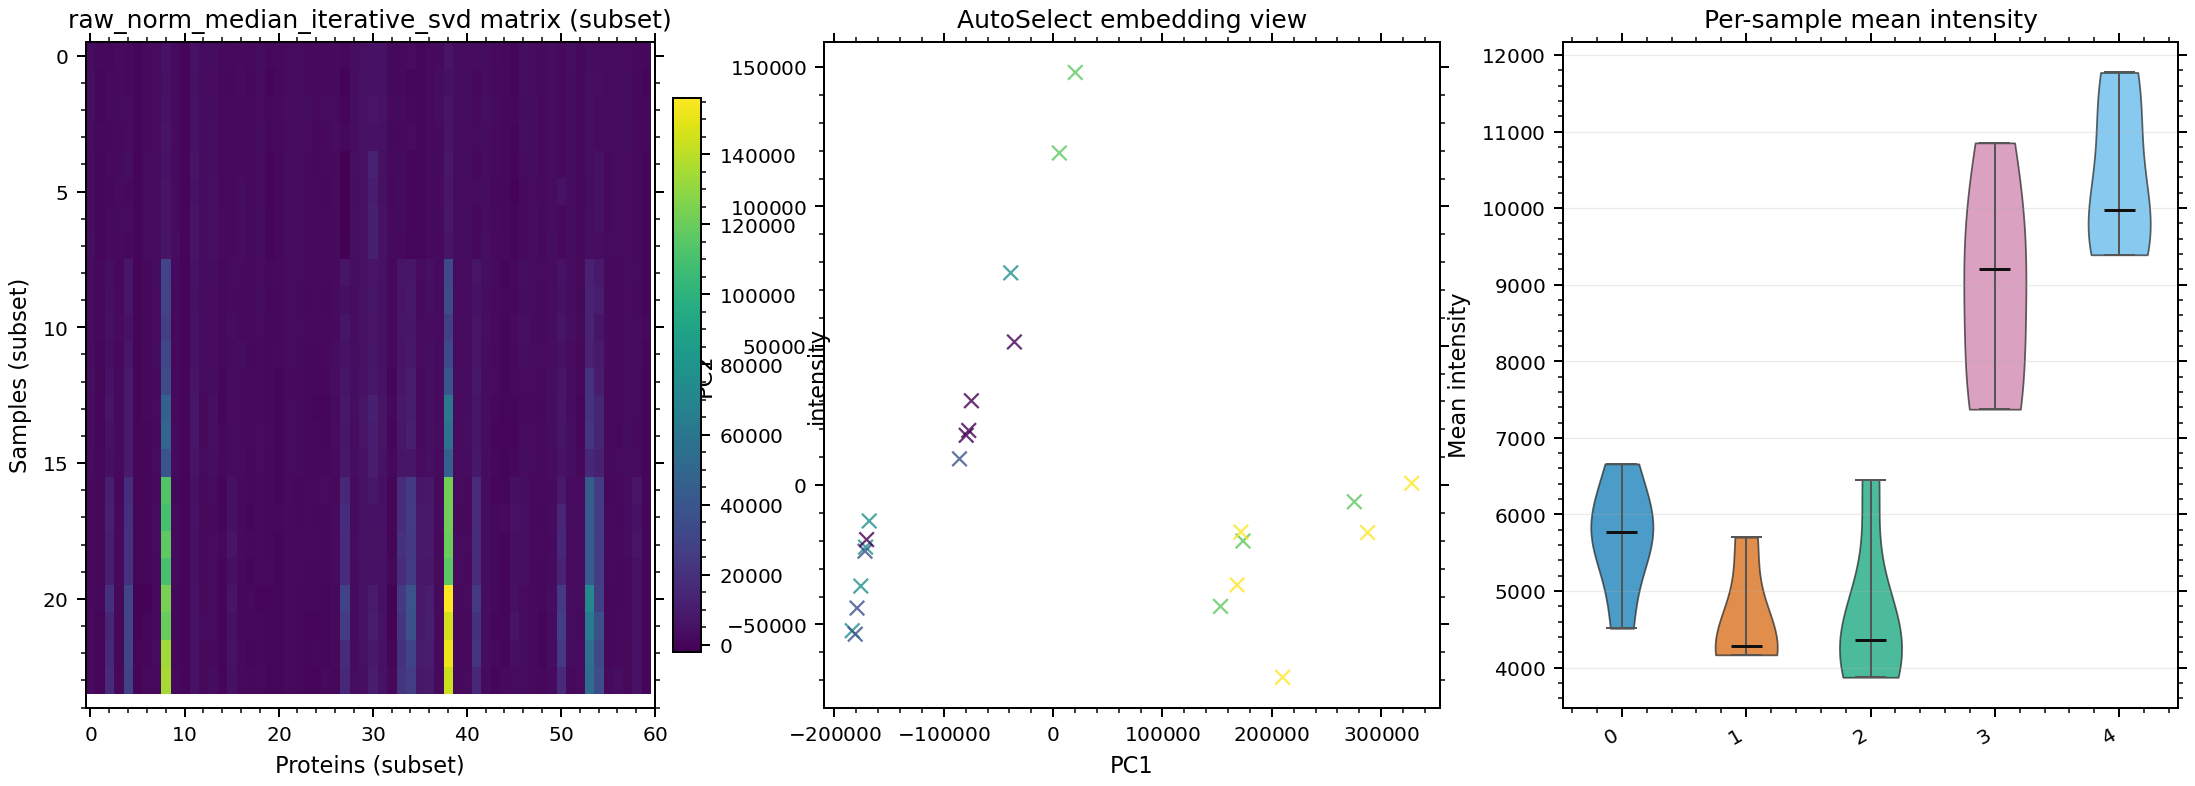

In [11]:
from scptensor.viz.base import PlotStyle, heatmap, scatter, violin

PlotStyle.apply_style(theme="science", dpi=300)

x_vis = container_imp.assays["proteins"].layers[imp_layer].X
x_vis = x_vis.toarray() if sp.issparse(x_vis) else np.asarray(x_vis)

m_raw = container_imp.assays["proteins"].layers["raw"].M
if m_raw is None:
    m_raw = np.zeros_like(x_vis, dtype=np.int8)
else:
    m_raw = m_raw.toarray() if sp.issparse(m_raw) else np.asarray(m_raw)

x_for_embed = np.nan_to_num(x_vis, nan=np.nanmedian(x_vis))
x_for_embed = x_for_embed - np.mean(x_for_embed, axis=0, keepdims=True)
u, s, _ = np.linalg.svd(x_for_embed, full_matrices=False)
coords = u[:, :2] * s[:2]

sample_has_missing = (m_raw != 0).any(axis=1).astype(np.int8)

cluster_key = None
if "cluster" in full_report.stages:
    cluster_key = full_report.stages["cluster"].output_obs_key

if cluster_key is not None and cluster_key in result_container.obs.columns:
    labels = result_container.obs[cluster_key].to_numpy().astype(str)
    _, color_values = np.unique(labels, return_inverse=True)
else:
    labels = np.where(sample_has_missing == 0, "measured", "contains_missing")
    _, color_values = np.unique(labels, return_inverse=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

n_rows = min(40, x_vis.shape[0])
n_cols = min(60, x_vis.shape[1])
heatmap(
    x_vis[:n_rows, :n_cols],
    m=m_raw[:n_rows, :n_cols],
    ax=axes[0],
    title=f"{imp_layer} matrix (subset)",
    cbar_label="intensity",
    xtick_rotation=0,
)
axes[0].set_xlabel("Proteins (subset)")
axes[0].set_ylabel("Samples (subset)")

scatter(
    coords,
    c=color_values,
    m=sample_has_missing,
    mask_style="explicit",
    ax=axes[1],
    title="AutoSelect embedding view",
    xlabel="PC1",
    ylabel="PC2",
    s=34,
)

labels = labels.astype(str)

violin_data = []
violin_labels = []
for lab in np.unique(labels):
    mask = labels == lab
    if np.any(mask):
        violin_data.append(np.nanmean(x_vis[mask], axis=1))
        violin_labels.append(str(lab))

violin(
    violin_data,
    violin_labels,
    ax=axes[2],
    title="Per-sample mean intensity",
    ylabel="Mean intensity",
    alpha=0.7,
)

plt.show()

## 7. 导出 AutoSelect 报告

In [12]:
report_dir = ROOT / "tutorial" / "_tutorial_outputs" / "autoselect"
report_dir.mkdir(parents=True, exist_ok=True)

md_path = report_dir / "autoselect_report.md"
json_path = report_dir / "autoselect_report.json"
csv_path = report_dir / "autoselect_report.csv"

full_report.save(md_path, format="markdown")
full_report.save(json_path, format="json")
full_report.save(csv_path, format="csv")

print(f"Saved: {md_path}")
print(f"Saved: {json_path}")
print(f"Saved: {csv_path}")

Saved: /home/shenshang/projects/ScpTensor/tutorial/_tutorial_outputs/autoselect/autoselect_report.md
Saved: /home/shenshang/projects/ScpTensor/tutorial/_tutorial_outputs/autoselect/autoselect_report.json
Saved: /home/shenshang/projects/ScpTensor/tutorial/_tutorial_outputs/autoselect/autoselect_report.csv


## 小结

- 稳定预处理快捷函数：`auto_normalize`、`auto_impute`、`auto_integrate`
- 实验性下游快捷函数：`auto_reduce`、`auto_cluster`
- `AutoSelector` 适合多阶段串联，并自动维护阶段上下文（layer/assay/obs 输出）。
- 报告对象支持 `summary()` 与 `save(..., format="markdown|json|csv")`，适合沉淀实验记录。
- 报告中的 `{source_layer}_{method_name}` 命名用于比较与追踪来源，不等同于 canonical `norm / imputed` 终态层名。
- 可视化：可直接复用 `viz.base` 的科研风格参数（`PlotStyle` + `heatmap/scatter/violin`）提升图形质量。